This notebook contains some experiment to tune the gleak and length parameters of the single-compartment model with grid searc, so the response it gives (especially the ramp up) matches the multi-compartment model's trace. First we don't include any channels, then we use passive models (only including leak channel). We use the gleak and length values we found optimal in these experiments as the default values for the single-compartment cells in all future experiments.

We always fix capacitance = 1.0

In [4]:
%load_ext autoreload
%autoreload 2


import os
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"

from jax import config
config.update("jax_enable_x64", True)


import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import jaxley as jx
import jax

**Finding good length value for the single point neuron WITHOUT any channels**

In [5]:
# Redefining the simulators without any channels

i_delay = 50.0
dt = 0.025
def setup_multi_simulator_no_channels(cell, t_max=200, v_init = -85.6, i_amp=100.0):
    i_dur = 1000.0
    time_vec = np.arange(0, t_max+2*dt, dt)
    levels = 3
    checkpoints = [int(np.ceil(len(time_vec)**(1/levels)).item()) for _ in range(levels)]
    
    # Build cell with approriate stimuli.
    cell.delete_stimuli()
    cell.delete_recordings()

    current = jx.step_current(i_delay, i_dur, i_amp, dt, t_max)

    cell.soma.branch(0).comp(0).stimulate(current)
    cell.soma.branch(0).comp(0).record()
    cell.set("v", v_init)
    cell.init_states()

    def simulate():
        pstate = None
        return jx.integrate(cell, param_state=pstate, checkpoint_lengths=checkpoints)
    
    return simulate
def setup_single_simulator_no_channels(cell, t_max=200, v_init = -85.6, i_amp=100.0):
    i_dur = 1000.0
    time_vec = np.arange(0, t_max+2*dt, dt)
    levels = 3
    checkpoints = [int(np.ceil(len(time_vec)**(1/levels)).item()) for _ in range(levels)]
    
    # Build cell with approriate stimuli.
    cell.delete_stimuli()
    cell.delete_recordings()

    current = jx.step_current(i_delay, i_dur, i_amp, dt, t_max)

    cell.stimulate(current)
    cell.record()
    cell.set("v", v_init)
    cell.init_states()

    def simulate():
        pstate = None
        return jx.integrate(cell, param_state=pstate, checkpoint_lengths=checkpoints)
    
    return simulate

/Users/moldor/Documents/Thesis/jaxley/jaxley/io/swc.py:305: UserWarning: Found a soma which consists of a single traced point. `Jaxley` interprets this soma as a spherical compartment with radius specified in the SWC file, i.e. with surface area 4*pi*r*r.
  warn(


dt_difference 5.0
Amplitude stimulus: 0.20999999344348907
Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


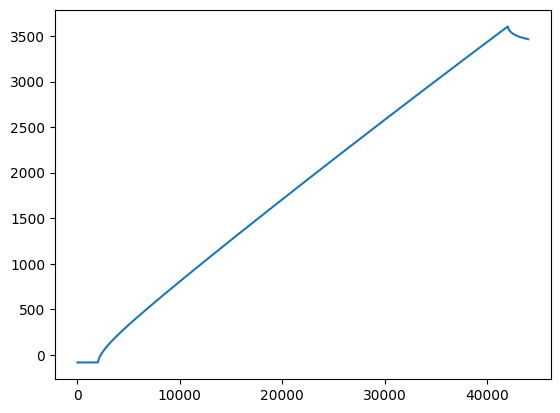

In [7]:
from voltage_fitting.build_simulator import (
    get_experimental_data,
    set_setup,
)


t_max = 1100.0
cut = 0

setup = "488683425"
#setup = "485574832"
#setup = "480353286"
#setup = "473601979"

all_setup = set_setup(setup)
cell = jx.read_swc(all_setup['swc_fname'], ncomp=4, max_branch_len=300.0, assign_groups=True)
cell.rotate(all_setup['rotation'])

t, x_o, i_amp = get_experimental_data(setup, cut, t_max)

simulate = setup_multi_simulator_no_channels(cell, t_max, all_setup["v_init"], i_amp)

v_multi_no_channels = simulate()
plt.plot(v_multi_no_channels[0])

In [8]:
#best length results with radius = 8
#'25': 113.5
#'32' 86.5 (54)
#'86': 81 (52)
#'79': 50.5 (12)

cell = jx.Cell()
cell.set("radius", 8)
cell.set("length", 113.5) #all_setup['length'])


simulate = setup_single_simulator_no_channels(cell, t_max, all_setup["v_init"], i_amp)

v_single_no_channels = simulate()


Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


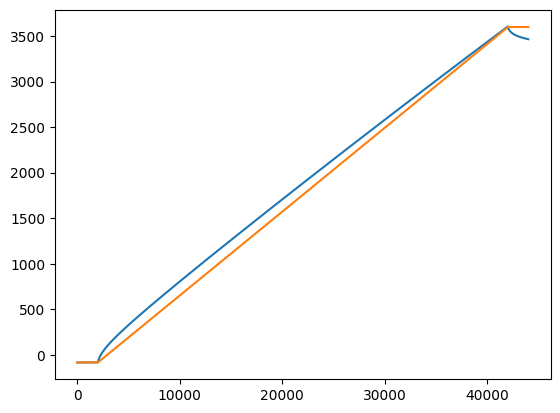

In [9]:
# '25'
plt.plot(v_multi_no_channels[0])
plt.plot(v_single_no_channels[0])

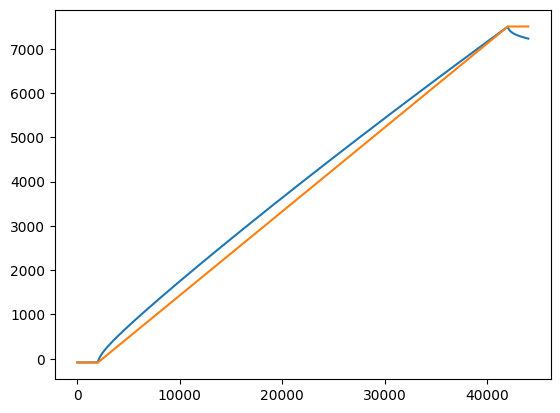

In [ ]:
# '32'
plt.plot(v_multi_no_channels[0])
plt.plot(v_single_no_channels[0])

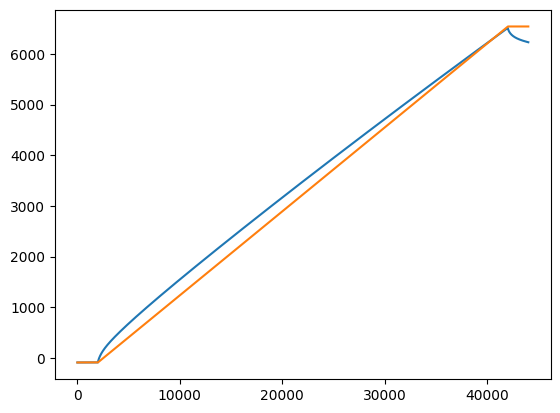

In [ ]:
# '86'
plt.plot(v_multi_no_channels[0])
plt.plot(v_single_no_channels[0])

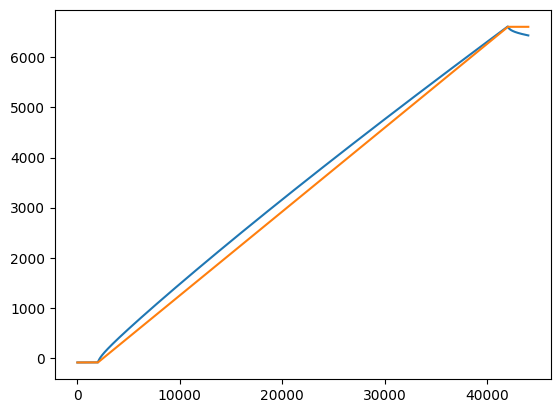

In [ ]:
# '79'
plt.plot(v_multi_no_channels[0])
plt.plot(v_single_no_channels[0])

**Finding the best possible length and gleak values with capacitance fixed to 1.0, using PASSIVE MODELS**

In [10]:
from voltage_fitting.build_simulator import (
    setup_passive_simulator,
    get_experimental_data,
    build_passive_cell,
    set_setup,
)


t_max = 1100.0
cut = 0
setup = "488683425"
# setup = "485574832"
# setup = "480353286"
# setup = "473601979"

all_setup = set_setup(setup)
cell = build_passive_cell(all_setup["swc_fname"], all_setup["rotation"], all_setup["capacitance"], all_setup["eleak"], all_setup["gleak"])

t, x_o, i_amp = get_experimental_data(setup, cut, t_max)

simulate = setup_passive_simulator(cell, t_max, all_setup["v_init"], i_amp)


v_multi = simulate()

/Users/moldor/Documents/Thesis/jaxley/jaxley/io/swc.py:305: UserWarning: Found a soma which consists of a single traced point. `Jaxley` interprets this soma as a spherical compartment with radius specified in the SWC file, i.e. with surface area 4*pi*r*r.
  warn(


dt_difference 5.0
Amplitude stimulus: 0.20999999344348907
Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


In [12]:
from voltage_fitting.single_build_simulator import (
    setup_passive_simulator,
    get_experimental_data,
    build_passive_cell,
    set_setup,
)
t_max = 1100.0
setup = "488683425"
# setup = "485574832"
# setup = "480353286"
# setup = "473601979"

#79 
#Active experiments:
#if I fix gleak = 1e-4, then len = 8.0, cap = 16
#if I fix length = 8, the min is cap = 15.5, gleak = 0.000155
#if I fix cap = 15.5, it is gleak = 0.000155, len = 8
#finish: 0.000175, len = 7.5, cap = 16.5

#Passive model result: length = 98, gleak = 5.09e-5

#86
#Active experiments:
#if gleak = 1e-4 fixed: length = 16, cap = 26
#if length = 16 fixed: gleak = 1.2e-4, cap = 26
#if cap = 26 fixed: gleak = 1.2e-4, length = 16
#finish: gleak = 1.2e-4, length = 16, cap = 26

#Passive model result: length = 277, gleak = 3.07e-5


#32 - is cap all right? If I limit the cap - significantly greater mismatch
#Active experiments:
#if I fix gleak = 1e-4, then length = 7, cap = 67
#if I fix length = 7, then gleak = 8.57e-5, cap = 67
#if I fix cap = 67, then gleak = 1e-8, length = 7.5
#finish: gleak = 8.57e-5, length = 7, cap = 67

#Passive model result: length = 410, gleak = 2.09e-5

#25
#Active experiments:
#if I fix gleak = 1e-4, then length = 30, cap = 7
#if I fix length = 30, then gleak = 9.6e-5, cap = 7.5 -2152
#if I fix cap = 7.5, then gleak = 7.22e-5, length = 31
#finish: gleak = 7.22e-5, length = 31, cap = 7.5

#Passive model result: length = 197, gleak = 5.545e-5

all_setup = set_setup(setup)
t, x_o, i_amp = get_experimental_data(setup, cut, t_max)

gleaks = np.linspace(1e-6, 5e-4, 11) 
lengths = np.linspace(50, 500, 113)
caps = [1.0] #np.linspace(1, 80, 41)

v_singles = []
diffs = []

i = 0
params_dict = {}

for gleak in gleaks:
    for length in lengths:
        print('length: ', length)
        print(' ')
        for cap in caps:
            params_dict[i] = [gleak, length, cap]
            i += 1

            cell = build_passive_cell(cap, all_setup["eleak"], gleak, length)
            simulate = setup_passive_simulator(cell, t_max, all_setup["v_init"], i_amp)

            v_single = simulate(v_multi[0], thr = None)
            v_singles.append(v_single)
            diff = sum(abs(v_single[0][0][:7000] - v_multi[0][:7000])) # Change the range based on which cell you use
            print('Difference:', diff)
            diffs.append(diff)
        print(' ')

diffs = [float(x) for x in diffs]

dt_difference 5.0
Amplitude stimulus: 0.20999999344348907
length:  50.0
 
Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
Difference: 2367854.7644380922
 
length:  54.017857142857146
 
Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
Difference: 2181522.476324157
 
length:  58.035714285714285
 
Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
Difference: 2020990.0434875325
 
length:  62.05357142857143
 
Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
Difference: 1881245.9832484436
 
length:  66.07142857142857
 
Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
Difference: 1758497.822227634
 
length:  70.08928571428572
 
Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recor

**Cap = 1.0, Passive model best results**

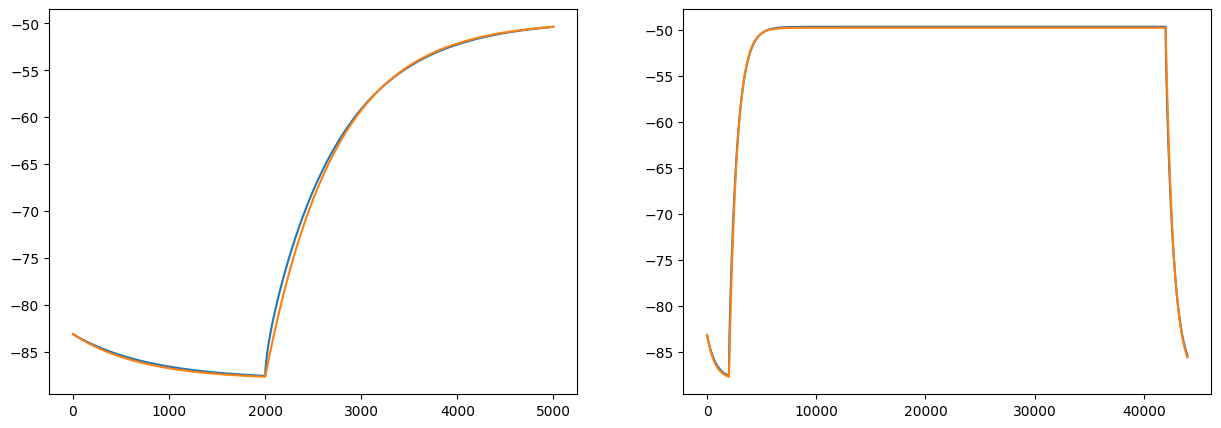

In [26]:
#'25'
fig, axs = plt.subplots(1,2, figsize = (15,5))
axs[0].plot(v_multi[0][:5000])
axs[0].plot(v_singles[1125][0][0][:5000])

axs[1].plot(v_multi[0])
axs[1].plot(v_singles[1125][0][0])

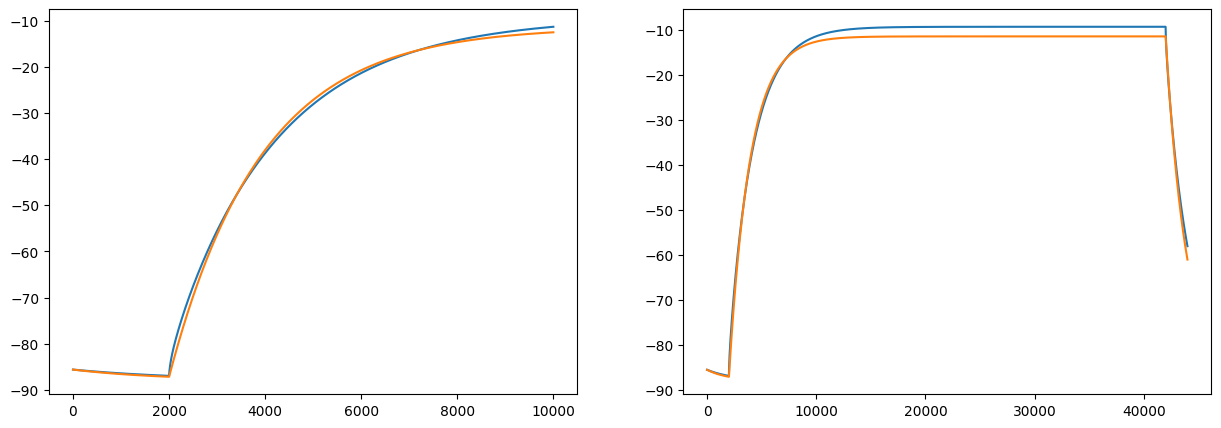

In [ ]:
#'32'
fig, axs = plt.subplots(1,2, figsize = (15,5))
axs[0].plot(v_multi[0][:10000])
axs[0].plot(v_singles[184][0][0][:10000])

axs[1].plot(v_multi[0])
axs[1].plot(v_singles[184][0][0])

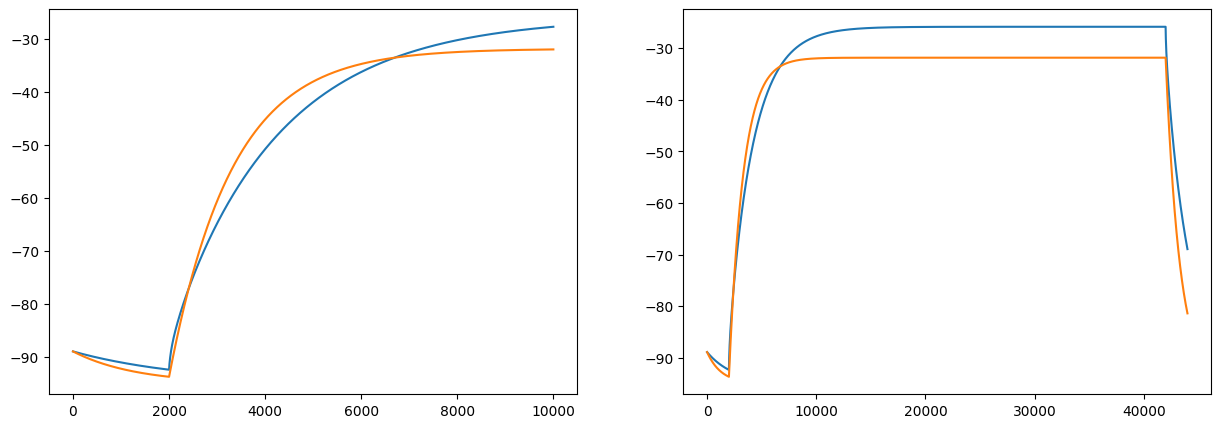

In [70]:
#'86'
fig, axs = plt.subplots(1,2, figsize = (15,5))
axs[0].plot(v_multi[0][:10000])
axs[0].plot(v_singles[520][0][0][:10000])

axs[1].plot(v_multi[0])
axs[1].plot(v_singles[520][0][0])

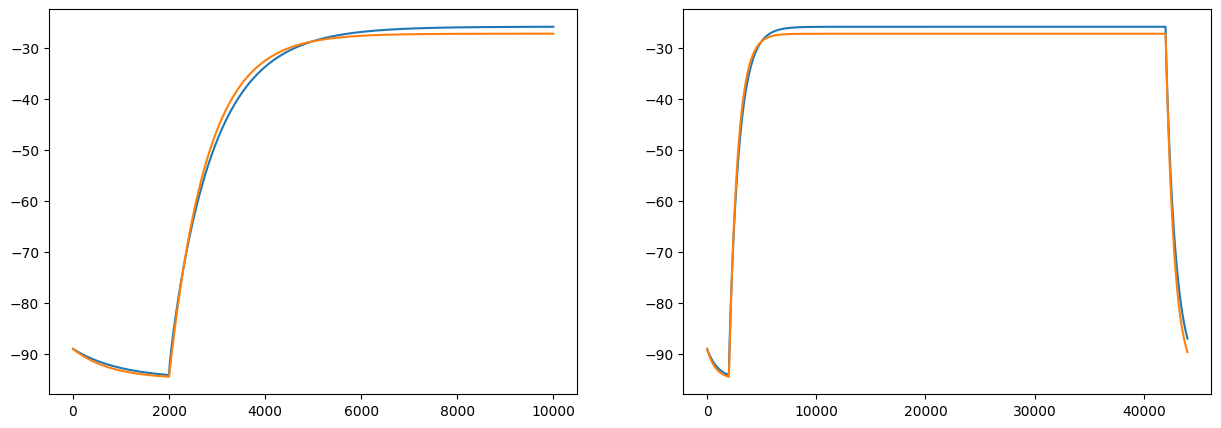

In [14]:
#'79'
fig, axs = plt.subplots(1,2, figsize = (15,5))
axs[0].plot(v_multi[0][:10000])
axs[0].plot(v_singles[198][0][0][:10000])

axs[1].plot(v_multi[0])
axs[1].plot(v_singles[198][0][0])

**Creating a plot including these 4 cells**

In [17]:
from voltage_fitting.build_simulator import (
    setup_passive_simulator,
    get_experimental_data,
    build_passive_cell,
    set_setup,
)

dt = 0.025
t_max = 1100.0
cut = 0
time_vec = np.arange(0, t_max+2*dt, dt)
setups = ["488683425", "485574832", "480353286", "473601979"]
v_multis = []
v_singles = []

for setup in setups:
    from voltage_fitting.build_simulator import (
        setup_passive_simulator,
        get_experimental_data,
        build_passive_cell,
        set_setup,
    )
    all_setup = set_setup(setup)
    cell = build_passive_cell(all_setup["swc_fname"], all_setup["rotation"], all_setup["capacitance"], all_setup["eleak"], all_setup["gleak"])
    t, x_o, i_amp = get_experimental_data(setup, cut, t_max)
    simulate = setup_passive_simulator(cell, t_max, all_setup["v_init"], i_amp)
    v_multi = simulate()
    v_multis.append(v_multi[0])

    from voltage_fitting.single_build_simulator import (
        setup_passive_simulator,
        get_experimental_data,
        build_passive_cell,
        set_setup,
    )

    all_setup = set_setup(setup)
    cell = build_passive_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'])
    t, x_o, i_amp = get_experimental_data(setup, cut, t_max)
    simulate = setup_passive_simulator(cell, t_max, all_setup["v_init"], i_amp)
    v_single = simulate(v_multi[0], thr = None)
    v_singles.append(v_single[0][0])

/Users/moldor/Documents/Thesis/jaxley/jaxley/io/swc.py:305: UserWarning: Found a soma which consists of a single traced point. `Jaxley` interprets this soma as a spherical compartment with radius specified in the SWC file, i.e. with surface area 4*pi*r*r.
  warn(


dt_difference 5.0
Amplitude stimulus: 0.20999999344348907
Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
dt_difference 5.0
Amplitude stimulus: 0.20999999344348907
Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


/Users/moldor/Documents/Thesis/jaxley/jaxley/io/swc.py:305: UserWarning: Found a soma which consists of a single traced point. `Jaxley` interprets this soma as a spherical compartment with radius specified in the SWC file, i.e. with surface area 4*pi*r*r.
  warn(


dt_difference 5.0
Amplitude stimulus: 0.33000001311302185
Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
dt_difference 5.0
Amplitude stimulus: 0.33000001311302185
Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


/Users/moldor/Documents/Thesis/jaxley/jaxley/io/swc.py:305: UserWarning: Found a soma which consists of a single traced point. `Jaxley` interprets this soma as a spherical compartment with radius specified in the SWC file, i.e. with surface area 4*pi*r*r.
  warn(


dt_difference 5.0
Amplitude stimulus: 0.26999998092651367
Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
dt_difference 5.0
Amplitude stimulus: 0.26999998092651367
Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


/Users/moldor/Documents/Thesis/jaxley/jaxley/io/swc.py:305: UserWarning: Found a soma which consists of a single traced point. `Jaxley` interprets this soma as a spherical compartment with radius specified in the SWC file, i.e. with surface area 4*pi*r*r.
  warn(


dt_difference 5.0
Amplitude stimulus: 0.17000000178813934
Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
dt_difference 5.0
Amplitude stimulus: 0.17000000178813934
Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


/var/folders/lr/9g81szbj4db_wp_gf2fdqlv00000gn/T/ipykernel_4095/2698290903.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_yticklabels([-100,-75,-50,-25,0])


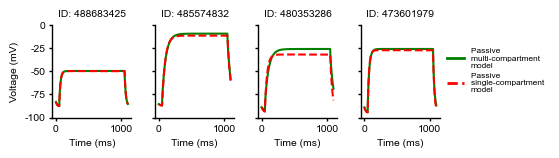

In [19]:
from matplotlib.lines import Line2D
with mpl.rc_context(fname="../../../.matplotlibrc"):
    fig, axs = plt.subplots(1, 4, figsize=(5, 1.2))
    fig.subplots_adjust(wspace=0.3)
    for i in range(4):
        axs[i].plot(time_vec, v_multis[i], c = 'g', linewidth = 1.5)
        axs[i].plot(time_vec, v_singles[i], '--',  c = 'r', linewidth = 1.5)
        axs[i].set_title(f"ID: {setups[i]}")
        axs[i].set_ylim(-100, 0)
        axs[i].set_yticklabels([])
        axs[i].set_xlabel("Time (ms)")
    axs[0].set_ylabel("Voltage (mV)")
    axs[0].set_yticklabels([-100,-75,-50,-25,0])
        
    legend_elements = [
        Line2D([0], [0], color='g', lw=2, label='Passive \nmulti-compartment \nmodel'),
        Line2D([0], [0], linestyle='--', color='r', lw=2, label='Passive \nsingle-compartment \nmodel'),
    ]

    # Add legend to the right of the figure
    fig.legend(
        handles=legend_elements,
        loc='center left',
        bbox_to_anchor=(0.9, 0.5),  # to the right of the plot
        frameon=False,
        fontsize = 6,
    )

    fig.savefig("../svg/passive_fit.svg")
    plt.show()

In [20]:
import time
import IPython.display as IPd
from svgutils.compose import *

def svg(img):
    IPd.display(IPd.HTML('<img src="{}" / >'.format(img, time.time())))

# > Inkscape pixel is 1/90 of an inch, other software usually uses 1/72.
# > http://www.inkscapeforum.com/viewtopic.php?f=6&t=5964
svg_scale = 1.25  # set this to 1.25 for Inkscape, 1.0 otherwise

# Panel letters in Helvetica Neue, 12pt, Medium
kwargs_text = {'size': '12pt', 'font': 'Arial', 'weight': '800'}

f = Figure("13.2cm", "3.8cm",
           
    Panel(
          SVG("../svg/passive_fit.svg").scale(svg_scale),
    ).move(0, 0),


)

#!mkdir -p fig
f.save("../fig/passive_fit.svg")
svg("../fig/passive_fit.svg")

**Finding the best possible length and gleak values with capacitance fixed to 1.0, so that the single-compartment recording matches the multi-compartment one, using ACTIVE MODELS**

**But the fit depends on the other parameters as well, so one gleak-length value pair is only optimal for that parameter compination!**

In [28]:
t_max = 80.0
cut = 1500  # We cut the first 1500 datapoints because this period contains no stimulus

# setup = "488683425"
# setup = "485574832"
# setup = "480353286"
setup = "473601979"

from voltage_fitting.build_simulator import (
    get_experimental_data
)

t, v_data, i_amp = get_experimental_data(setup, cut, t_max)


dt_difference 5.0
Amplitude stimulus: 0.17000000178813934


In [29]:
# Define the multi-compartment cell to train
from voltage_fitting.build_simulator import (
    setup_simulator,
    build_cell,
    set_setup,
    get_bounds,
    transform_uniform_to_normal,
    get_prior
)

seed = 0

rng_key = jax.random.PRNGKey(seed)

all_setup = set_setup(setup)
cell = build_cell(all_setup["swc_fname"], all_setup["rotation"], all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'])
simulate = setup_simulator(cell, cut, t_max, all_setup["v_init"], i_amp)

/Users/moldor/Documents/Thesis/jaxley/jaxley/io/swc.py:305: UserWarning: Found a soma which consists of a single traced point. `Jaxley` interprets this soma as a spherical compartment with radius specified in the SWC file, i.e. with surface area 4*pi*r*r.
  warn(


Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


Number of parameters: 25


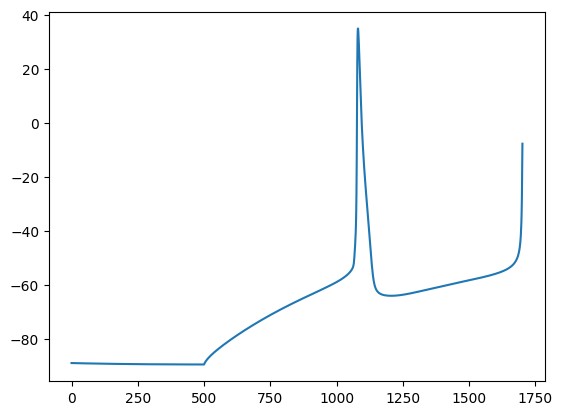

In [30]:
names, lower, upper = get_bounds()


transform_params, inv_transform_params = transform_uniform_to_normal(lower, upper)
sample_prior = get_prior(lower, upper, transform_params)

init_rng_key, sampling_rng_key = jax.random.split(rng_key)

# Sample 1 initialization randomly.
sampled_params = sample_prior(init_rng_key)
inv_sampled_params = inv_transform_params(sampled_params)

v_multi = simulate(inv_sampled_params)
plt.plot(v_multi[0])

In [ ]:
from voltage_fitting.single_build_simulator import (
    setup_simulator,
    get_experimental_data,
    build_cell,
    set_setup,
    get_bounds,
)
t_max = 80.0
# setup = "488683425"
# setup = "485574832"
# setup = "480353286"
setup = "473601979"

#25: 1e-4, 142
#32: 1.25e-4, 220
#86: 8.06e-5, 216
#79: 1.05e-4, 80


names, lower, upper = get_bounds()


transform_params, inv_transform_params = transform_uniform_to_normal(lower, upper)
sample_prior = get_prior(lower, upper, transform_params)

init_rng_key, sampling_rng_key = jax.random.split(rng_key)

# Sample 1 initialization randomly.
sampled_params = sample_prior(init_rng_key)
inv_sampled_params = inv_transform_params(sampled_params)



gleaks = np.linspace(1e-5, 2e-4, 11) 
lengths = np.linspace(10, 200, 100)
caps = [1.0] #np.linspace(1, 80, 41)

v_singles = []
diffs = []

i = 0
params_dict = {}

for gleak in gleaks:
    for length in lengths:
        print('length: ', length)
        print(' ')
        for cap in caps:
            params_dict[i] = [gleak, length, cap]
            i += 1
            all_setup = set_setup(setup)


            cell = build_cell(cap, all_setup["eleak"], gleak, length)
            
            simulate = setup_simulator(cell, cut, t_max, all_setup["v_init"], i_amp)

            v_single = simulate(inv_sampled_params, v_multi[0], thr = None)
            v_singles.append(v_single)
            diff = sum(abs(v_single[0][0][:1000] - v_multi[0][:1000])) # Change the range based on which cell you use
            print('Difference:', diff)
            diffs.append(diff)
        print(' ')

diffs = [float(x) for x in diffs]

Number of parameters: 15
length:  10.0
 
Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
Difference: 12934.309128999668
 
length:  11.919191919191919
 
Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
Difference: 12934.309128999668
 
length:  13.838383838383837
 
Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
Difference: 12934.309128999668
 
length:  15.757575757575758
 
Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
Difference: 12934.309128999668
 
length:  17.676767676767675
 
Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
Difference: 12934.309128999668
 
length:  19.595959595959595
 
Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
Differen

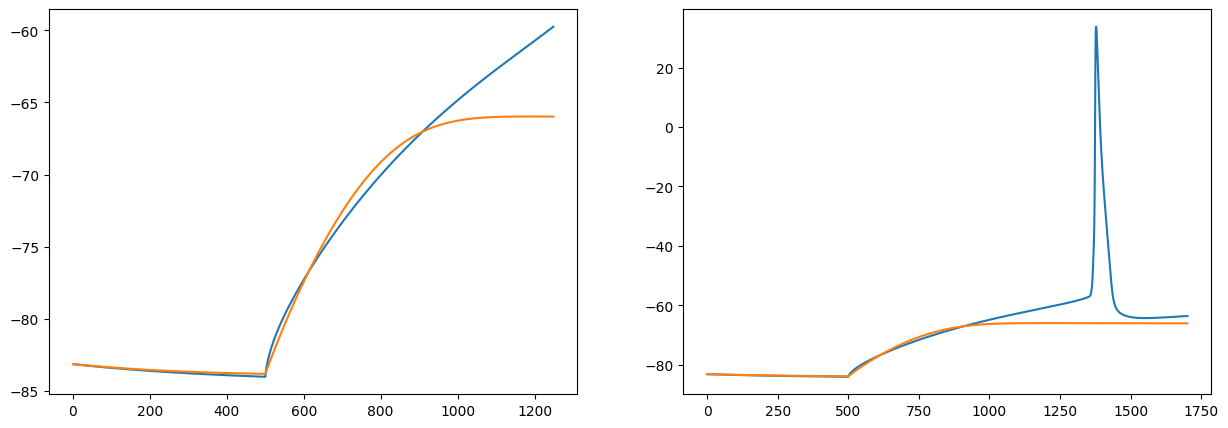

In [22]:
#'25'
fig, axs = plt.subplots(1,2, figsize = (15,5))
axs[0].plot(v_multi[0][:1250])
axs[0].plot(v_singles[242][0][0][:1250])

axs[1].plot(v_multi[0])
axs[1].plot(v_singles[242][0][0])

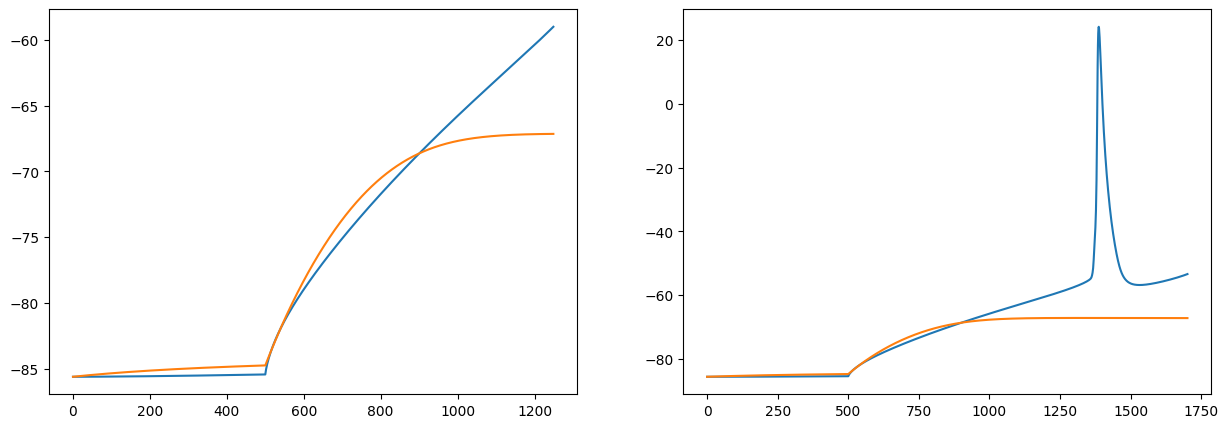

In [29]:
#'32'
fig, axs = plt.subplots(1,2, figsize = (15,5))
axs[0].plot(v_multi[0][:1250])
axs[0].plot(v_singles[346][0][0][:1250])

axs[1].plot(v_multi[0])
axs[1].plot(v_singles[346][0][0])

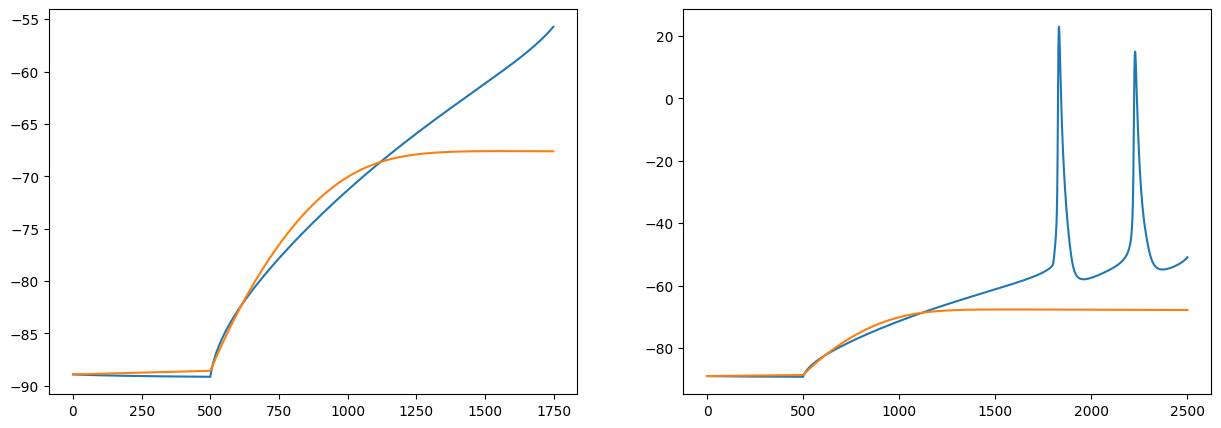

In [29]:
#'86'
fig, axs = plt.subplots(1,2, figsize = (15,5))
axs[0].plot(v_multi[0][:1750])
axs[0].plot(v_singles[409][0][0][:1750])

axs[1].plot(v_multi[0])
axs[1].plot(v_singles[409][0][0])

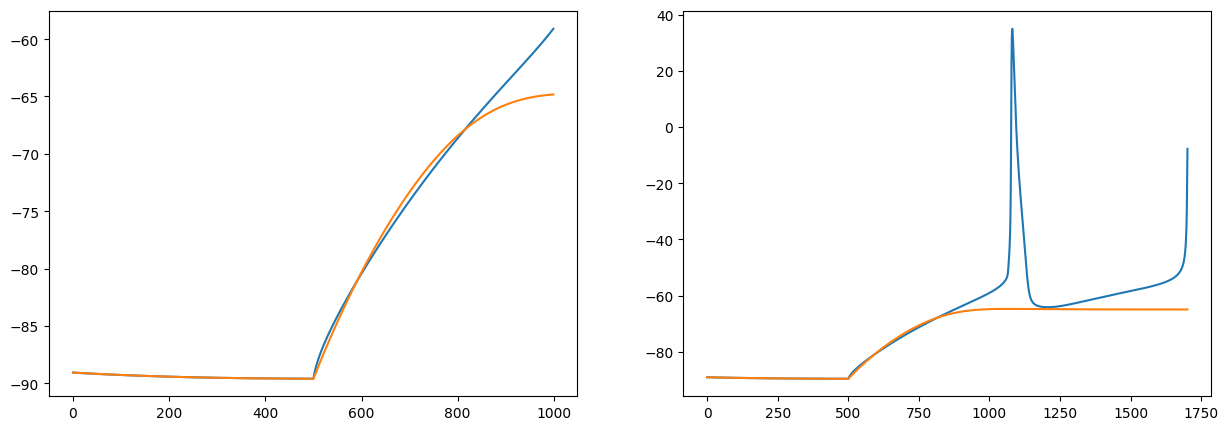

In [9]:
#'79'
fig, axs = plt.subplots(1,2, figsize = (15,5))
axs[0].plot(v_multi[0][:1000])
axs[0].plot(v_singles[536][0][0][:1000])

axs[1].plot(v_multi[0])
axs[1].plot(v_singles[536][0][0])

**The match is different if we change the seed:**

In [ ]:
from voltage_fitting.single_build_simulator import (
    setup_simulator,
    get_experimental_data,
    build_cell,
    set_setup,
    get_bounds,
)
t_max = 80.0

# setup = "488683425"
# setup = "485574832"
# setup = "480353286"
setup = "473601979"

all_setup = set_setup(setup)

seed = 1

rng_key = jax.random.PRNGKey(seed)


names, lower, upper = get_bounds()


transform_params, inv_transform_params = transform_uniform_to_normal(lower, upper)
sample_prior = get_prior(lower, upper, transform_params)

init_rng_key, sampling_rng_key = jax.random.split(rng_key)

# Sample 1 initialization randomly.
sampled_params = sample_prior(init_rng_key)
inv_sampled_params = inv_transform_params(sampled_params)

cell = build_cell(cap, all_setup["eleak"], all_setup['gleak'], all_setup['length'])
t, v_data, i_amp = get_experimental_data(setup, cut, t_max)   
simulate = setup_simulator(cell, cut, t_max, all_setup["v_init"], i_amp)

v_single = simulate(inv_sampled_params, v_multi[0], thr = None)

Number of parameters: 15
dt_difference 5.0
Amplitude stimulus: 0.17000000178813934
Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


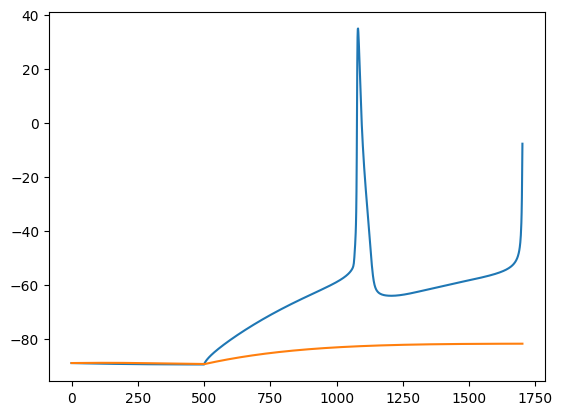

In [40]:
plt.plot(v_multi[0])
plt.plot(v_single[0][0])